# 🚗📝 Project : Insurance Marketing Campaigns with Predictive Modeling (Kaggle Challenge s4e7)
The objective of this project, based on the **Kaggle Playground Series - Season 4, Episode 7** challenge, was to build a machine learning classification 
https://www.kaggle.com/competitions/playground-series-s4e7
## 🎯 Project Goal
The objective of this competition is to predict which customers respond positively to an automobile insurance offer.  
**Evaluation :**
Submissions are evaluated using **area under the ROC curve** using the predicted probabilities and the ground truth targets
## 📈 Kaggle Performance
**Accuracy Score: 0.89515**  
**Ranking (rank/all competitors): 344/2234**  
https://www.kaggle.com/makowskia/competitions
## 🛠️ Methodology and Pipeline
1. **Data Preprocessing and Feature Engineering:**  One-Hot Encoding (OHE) 
2. **Tiered Modeling Strategy:** Compared multiple machine learning classifiers:
    - **Random Forest Classifier**  
    - **XGBoost Classifier**  
    - **LGBMClassifier**  
    - **CatBoostClassifier**  
3. **Hyperparameter Tuning for CatBoostClassifier**  
   - Manual grid search over learning rate, depth, and regularization
   - Used Logloss for early stopping
   - Evaluated final model using AUC
4. **Evaluation Results Based on Logloss and ROC AUC**
   - Visualized performance using charts for both metrics
   - Assessed model stability and ranking ability
5. **CatBoostClassifier Evaluation**
    - The top 4 parameter combinations were selected based on validation performance using Logloss and cross-validation during tuning.
    - Each of these models was re-evaluated using ROC AUC on the validation set, with predicted probabilities, to align with the competition metric.
    - AUC was not used for early stopping, but calculated after training to guide final model selection before applying K-Fold cross-validation.
6. **K-fold for Catboost** model with best parameters from catboost tuning  
## ⚖️ Evaluatio ROC AUC  
It measures how well the model ranks positive vs. negative samples across all classification thresholds.

    - Suitable for imbalanced datasets
    - Outputs a score between 0.5 (random guessing) and 1.0 (perfect ranking)
    - Used consistently during validation and final evaluation

In [1]:
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
import time 
import numpy as np 
import winsound
import os
import pickle
import gc

# === GLOBAL VARIABLES AND CONFIGURATION ===

# Column Names
ID_COLUMN = 'id'  # Unique identifier for each sample; useful for verifying whether the model predicted the correct outcome for a specific mushroom
TARGET_COLUMN = 'Response'  # Target label indicating mushroom edibility: 'p' for poisonous, 'e' for edible

# Data Splitting Parameters
VALIDATION_SPLIT_SIZE =0.25
RANDOM_STATE =42

# Data Paths
DATA_SUBFOLDER = 'DATA_reduced_to_size_under_100_MB'
TRAIN_FILE_PATH = os.path.join(DATA_SUBFOLDER, "train.csv")
TEST_FILE_PATH = os.path.join(DATA_SUBFOLDER, "test.csv")

# Table display settings
full_table_display = True
if full_table_display :
    # Display configuration
    pd.set_option('display.max_columns', None)  # Show all columns
    pd.set_option('display.expand_frame_repr', False)  # Prevent line wrapping
    
# Numbers display settings
# pd.set_option('display.float_format', '{:.5f}'.format)


## 💾 Loading and Initial Data Preprocessing
This section is about reading the data from CSV files,  
setting the unique **ID** column as the table index,  
and making sure the feature sets (columns) for the training and testing data match.  
It also separates the **target column** (`Response` - what we want to predict) from the **features** (the characteristics used for prediction).

In [2]:

CHUNK_FOLDER ="DATA_chunks_by_size"

# Helper function to filter and sort files
def get_chunk_files(folder, prefix):
    all_files = os.listdir(folder)
    chunk_files = []
    for f in all_files:
        if f.startswith(prefix) and f.endswith(".csv"):
            chunk_files.append(f)
    chunk_files_sorted = sorted(chunk_files)
    full_paths = []
    for f in chunk_files_sorted:
        full_paths.append(os.path.join(folder, f))
    return full_paths

# Load and concatenate training files
train_files = get_chunk_files(CHUNK_FOLDER, "train_")
print("train_files ",train_files)
df_train_received = pd.concat([pd.read_csv(f) for f in train_files], ignore_index=True)

# Load and concatenate test files
test_files = get_chunk_files(CHUNK_FOLDER, "test_")
print("test_files ",test_files)
df_test_received = pd.concat([pd.read_csv(f) for f in test_files], ignore_index=True)

print("\nlen(df_train_received) ",len(df_train_received))
print("len(df_test_received) ",len(df_test_received),"\n")

train_files  ['DATA_chunks_by_size\\train_1.csv', 'DATA_chunks_by_size\\train_2.csv', 'DATA_chunks_by_size\\train_3.csv', 'DATA_chunks_by_size\\train_4.csv', 'DATA_chunks_by_size\\train_5.csv', 'DATA_chunks_by_size\\train_6.csv', 'DATA_chunks_by_size\\train_7.csv']
test_files  ['DATA_chunks_by_size\\test_1.csv', 'DATA_chunks_by_size\\test_2.csv', 'DATA_chunks_by_size\\test_3.csv', 'DATA_chunks_by_size\\test_4.csv', 'DATA_chunks_by_size\\test_5.csv']

len(df_train_received)  11504798
len(df_test_received)  7669866 



In [3]:

fraction = int(len(df_test_received))
print("fraction ",fraction)
df_train_received = df_train_received.iloc[:fraction]
print("New length of df_train_received:", len(df_train_received))

# Set the 'id' column as the index for easier tracking
df_train_received = df_train_received.set_index(ID_COLUMN)
df_test_received = df_test_received.set_index(ID_COLUMN)

# Store test and full training indices for later use (before validation split)
train_indices_full = df_train_received.index.values
test_indices = df_test_received.index.values
print(test_indices)
# Check if the only difference between train and test sets is the target column
print('\n Difference between train and test columns ',df_train_received.columns.drop(df_test_received.columns))

# Separate target and features from training set
y_train_full = df_train_received[TARGET_COLUMN]                # I keep here ansers for trainig set ('e' or 'p')
X_train_full = df_train_received.drop(columns=[TARGET_COLUMN]) # I keep here parameters - features

# Preview the result
print("\nFirst 5 target labels\n", y_train_full.head())
X_train_full.head()

fraction  7669866
New length of df_train_received: 7669866
[11504798 11504799 11504800 ... 19174661 19174662 19174663]

 Difference between train and test columns  Index(['Response'], dtype='object')

First 5 target labels
 id
0    0
1    1
2    0
3    0
4    0
Name: Response, dtype: int64


,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
id,,,,,,,,,,
0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187
1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288
2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254
3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76
4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294


## 🔪 Data Splitting
In machine learning workflows, datasets are typically divided into three key subsets:

1. **Training set** – used to train the model.
2. **Validation set** – used to tune hyperparameters and monitor model performance during training.
3. **Test set** – used at the final stage to evaluate how well the model generalizes to unseen data.

🎯 Why split the data?
- **Prevents overfitting** – the model learns general patterns instead of memorizing the data.
- **Ensures generalization** – we test how well the model performs on new, unseen samples.
- **Supports optimization** – the validation set helps select the best model configuration without compromising the integrity of the test set.

🔀 The data is split randomly into subsets, ensuring that samples are drawn from different parts of the dataset. This helps maintain diversity and representativeness across the training and validation sets. By doing so, the model is exposed to a broad range of examples during training and evaluation, which is especially important when dealing with uneven or complex data distributions.

In [4]:
# --- DATA SPLIT: Train and Validation ---
X_train_full_data = df_train_received.drop([TARGET_COLUMN], axis=1)
y_train_full_data = df_train_received[TARGET_COLUMN]

X_train_split, X_valid_split, y_train_split, y_valid_split = train_test_split(
    X_train_full_data, y_train_full_data,
    test_size=VALIDATION_SPLIT_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full_data
)
train_indices = X_train_split.index.values
valid_indices = X_valid_split.index.values

print(f"Total training data size: {len(X_train_full)}")
print(f"New Train Set size: {len(X_train_split)}")
print(f"Validation Set size: {len(X_valid_split)}")

# Free memory
del y_train_full_data
gc.collect()

Total training data size: 7669866
New Train Set size: 5752399
Validation Set size: 1917467


0

# 📊 Feature Identification and Data Overview (EDA)

## The target classes are imbalanced thas wy AUC ROC is the right metric to evaluate accurecy

In [5]:
counts = y_train_full.value_counts()
print(f"\nThe target classes are imbalanced:\n{counts}\n")

percentage = y_train_full.sum()/len(y_train_full)*100
print(f"Percentage of clients who signed a new insurance contract: {percentage:.2f}%")


The target classes are imbalanced:
Response
0    6726537
1     943329
Name: count, dtype: int64

Percentage of clients who signed a new insurance contract: 12.30%


In [6]:
# Nie trzeba tworzyć słownika jeżeli jasne jest co jest w kolumnach
# dict_columns={}

# Splitting Columns by Data Type: Numerical vs Categorical
list_num_columns = ['Age','Annual_Premium','Policy_Sales_Channel','Vintage']

list_cat_columns = ['Gender','Driving_License','Region_Code','Previously_Insured',
                     'Vehicle_Damage','Vehicle_Age']

if (len(list_num_columns) + len(list_cat_columns))== len(X_train_full_data.columns.values):
    print('All columns define')

print(X_train_full_data.info())
print('Count of Nan values in ech column')
print(X_train_full_data.isnull().sum())
print('\nThere are no missing values\n')
print('Statistic for numeral columns')
print(X_train_full_data[list_num_columns].describe())

print('Uniq values in categorical columns')
print(X_train_full_data[list_cat_columns].nunique())

All columns define
<class 'pandas.core.frame.DataFrame'>
Index: 7669866 entries, 0 to 7669865
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Gender                object 
 1   Age                   int64  
 2   Driving_License       int64  
 3   Region_Code           float64
 4   Previously_Insured    int64  
 5   Vehicle_Age           object 
 6   Vehicle_Damage        object 
 7   Annual_Premium        float64
 8   Policy_Sales_Channel  float64
 9   Vintage               int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 643.7+ MB
None
Count of Nan values in ech column
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
dtype: int64

There are no missing values

Statistic for numeral columns
                A

In [7]:
def map_column_values(df, column_name, value_map):
    """
    Replace values in a DataFrame column based on a mapping dictionary.
    
    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - column_name (str): The name of the column to transform.
    - value_map (dict): A dictionary mapping old values to new ones.

    Returns:
    - pd.DataFrame: The modified DataFrame with updated values in the specified column.
    """
    for key, value in value_map.items():
        mask = (df[column_name] == key)
        df.loc[mask, column_name] = value
    return df

In [8]:
def transform (df, data_name , print_transform = False):
    
    map_dict = {'Yes':1,'No':0}
    df = map_column_values(df_train_test,'Vehicle_Damage',map_dict)
    
    map_dict = {'Male':1,'Female':0}
    df = map_column_values(df_train_test,'Gender',map_dict)
    
    map_dict = {'1-2 Year':0,'< 1 Year':1,'> 2 Years':2}
    df = map_column_values(df_train_test,'Vehicle_Age',map_dict)
    
    print('Original data types ',df.info())

    df['Gender'] = df['Gender'].astype('bool')
    df['Driving_License'] = df['Driving_License'].astype('bool')
    df['Previously_Insured'] = df['Previously_Insured'].astype('bool')
    df['Vehicle_Damage'] = df['Vehicle_Damage'].astype('bool')
    df['Vehicle_Age'] = df['Vehicle_Age'].astype('int8')
    
    df['Region_Code'] = df['Region_Code'].astype('int16')    
    df['Annual_Premium'] = df['Annual_Premium'].astype('int32')
    df['Policy_Sales_Channel'] = df['Policy_Sales_Channel'].astype('int16')   
    
    print('Data types after transformation ',df.info())

    print(df.head())

    return(df)

## DATA transformation

In [9]:
df_train_test = pd.concat([df_train_received, df_test_received])
df_train_test = df_train_test.drop([TARGET_COLUMN],axis = 1)
df_all_data = transform(df_train_test,'ALL DATA',print_transform = True)

X_train= df_all_data.loc[train_indices]
y_train= y_train_full.loc[train_indices].values

X_valid= df_all_data.loc[valid_indices]
y_valid= y_train_full.loc[valid_indices].values

X_test= df_all_data.loc[test_indices]

df_all_data = None
df_train_test = None

<class 'pandas.core.frame.DataFrame'>
Index: 15339732 entries, 0 to 19174663
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Gender                object 
 1   Age                   int64  
 2   Driving_License       int64  
 3   Region_Code           float64
 4   Previously_Insured    int64  
 5   Vehicle_Age           object 
 6   Vehicle_Damage        object 
 7   Annual_Premium        float64
 8   Policy_Sales_Channel  float64
 9   Vintage               int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 1.3+ GB
Original data types  None
<class 'pandas.core.frame.DataFrame'>
Index: 15339732 entries, 0 to 19174663
Data columns (total 10 columns):
 #   Column                Dtype
---  ------                -----
 0   Gender                bool 
 1   Age                   int64
 2   Driving_License       bool 
 3   Region_Code           int16
 4   Previously_Insured    bool 
 5   Vehicle_Age           int8 
 6   Veh

In [10]:
def cat_One_hot_encoding(df,list_cat_columns,list_num_columns,columns_after_train_encoded=None):

    train_cols = columns_after_train_encoded

    df = pd.get_dummies(df,columns = list_cat_columns,drop_first=True)
    
    # Find all columns created by one-hot encoding (everything except numeric columns)
    one_hot_encoded_columns = df.columns.difference(list_num_columns)
    
    # Check if one-hot encoded columns contain only 0 or 1 values
    for col in one_hot_encoded_columns:
        if not df[col].dropna().apply(lambda x: x in [0, 1]).all():
            print(f"Non-binary values found in column: {col}")
            print(df[col].unique())

    # Convert one-hot encoded columns to integer type (0 or 1)
    df[one_hot_encoded_columns] = df[one_hot_encoded_columns].astype(int)
    # If training columns are provided, reindex to match them and fill missing columns with 0
    if not train_cols is None:
        df = df.reindex(columns=train_cols, fill_value=0)
    return df

## One_hot_encoding

In [11]:

X_train_ohe = cat_One_hot_encoding(X_train,list_cat_columns,list_num_columns)
X_valid_ohe = cat_One_hot_encoding(X_valid,list_cat_columns,list_num_columns,X_train_ohe.columns)
df_test_ohe = cat_One_hot_encoding(X_test,list_cat_columns,list_num_columns,X_train_ohe.columns)

X_train_ohe = X_train_ohe.fillna(0)
X_valid_ohe = X_valid_ohe.fillna(0)
df_test_ohe = df_test_ohe.fillna(0)

X_valid_ohe.head()

,Age,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_True,Driving_License_True,Region_Code_1,Region_Code_2,Region_Code_3,Region_Code_4,Region_Code_5,Region_Code_6,Region_Code_7,Region_Code_8,Region_Code_9,Region_Code_10,Region_Code_11,Region_Code_12,Region_Code_13,Region_Code_14,Region_Code_15,Region_Code_16,Region_Code_17,Region_Code_18,Region_Code_19,Region_Code_20,Region_Code_21,Region_Code_22,Region_Code_23,Region_Code_24,Region_Code_25,Region_Code_26,Region_Code_27,Region_Code_28,Region_Code_29,Region_Code_30,Region_Code_31,Region_Code_32,Region_Code_33,Region_Code_34,Region_Code_35,Region_Code_36,Region_Code_37,Region_Code_38,Region_Code_39,Region_Code_40,Region_Code_41,Region_Code_42,Region_Code_43,Region_Code_44,Region_Code_45,Region_Code_46,Region_Code_47,Region_Code_48,Region_Code_49,Region_Code_50,Region_Code_51,Region_Code_52,Previously_Insured_True,Vehicle_Damage_True,Vehicle_Age_1,Vehicle_Age_2
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3969699,36,26429,163,89,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
568381,41,33870,124,219,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4413174,25,34709,152,163,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0
5914045,41,35354,124,95,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1487918,52,33171,124,228,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0


In [12]:
# chenging categorical columns to data type 'category'
print("list_cat_columns ",list_cat_columns)
print("\nBefore conversion:")
print(X_train.info())

X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()
X_test_cat = X_test.copy()

for col in list_cat_columns:
    X_train_cat[col] = X_train[col].astype('category')
    X_valid_cat[col] = X_valid[col].astype('category')
    X_test_cat[col] = X_test[col].astype('category')
    
print("\nAfter conversion:")
print(X_train_cat.info())

list_cat_columns  ['Gender', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Damage', 'Vehicle_Age']

Before conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 5752399 entries, 5960622 to 464116
Data columns (total 10 columns):
 #   Column                Dtype
---  ------                -----
 0   Gender                bool 
 1   Age                   int64
 2   Driving_License       bool 
 3   Region_Code           int16
 4   Previously_Insured    bool 
 5   Vehicle_Age           int8 
 6   Vehicle_Damage        bool 
 7   Annual_Premium        int32
 8   Policy_Sales_Channel  int16
 9   Vintage               int64
dtypes: bool(4), int16(2), int32(1), int64(2), int8(1)
memory usage: 203.0 MB
None

After conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 5752399 entries, 5960622 to 464116
Data columns (total 10 columns):
 #   Column                Dtype   
---  ------                -----   
 0   Gender                category
 1   Age                   int

# 🧠 Modeling Strategy
This section outlines the full modeling pipeline used to tackle the binary classification task.  
The goal is to predict whether a client will sign a new insurance contract (target = 1).

In [13]:
df_model_results = pd.DataFrame() 

In [14]:
def train_model(model_type, X_train, y_train, X_valid, y_valid, params=None, results_df=None):
    """
    Trains a selected model and evaluates it using ROC AUC.
    """
    import time
    from datetime import datetime
    from sklearn.metrics import roc_auc_score
    import pandas as pd

    start_time = time.time()
    current_time = datetime.now().strftime("%H:%M:%S")

    # --- Model Selection ---
    if model_type == 'xgboost':
        import xgboost as xgb
        base_model = xgb.XGBClassifier()
    elif model_type == 'lightgbm':
        import lightgbm as lgb
        base_model = lgb.LGBMClassifier()
    elif model_type == 'random_forest':
        from sklearn.ensemble import RandomForestClassifier
        base_model = RandomForestClassifier()
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    # --- Merge with default parameters ---
    if params is not None:
        default_params = base_model.get_params()
        default_params.update(params)
        base_model.set_params(**default_params)

    model = base_model

    # --- Training ---
    model.fit(X_train, y_train)

    # --- Evaluation ---
    p_valid = model.predict_proba(X_valid)[:, 1]
    auc_score = roc_auc_score(y_valid, p_valid)
    duration = (time.time() - start_time) / 60

    print(f"\n[{model_type.upper()}] ROC AUC: {auc_score:.5f} | Time: {duration:.2f} min")

    # --- Logging ---
    log_entry = {
        "model_name": model_type,
        "score": round(auc_score, 5),
        "duration_min": round(duration, 2),
        "timestamp": current_time,
        **model.get_params()
    }

    if results_df is None:
        results_df = pd.DataFrame([log_entry])
    else:
        results_df = pd.concat([results_df, pd.DataFrame([log_entry])], ignore_index=True)

    return model, model.get_params(), results_df

## RandomForestClassifier
🧠 Data Prep Summary  
Random Forest is a **tree-based ensemble method** that builds multiple decision trees and averages their predictions. Unlike boosting methods, it trains trees independently and is robust to overfitting and noise.

**✅ 1. Categorical Features Must be encoded** — Random Forest does not support categorical variables natively. **One-Hot Encoding** 

**✅ 2. Scaling Not needed** — tree models are scale-invariant. Raw numerical values are fine.

**✅ 3. Missing Values Not handled automatically** — you need to impute missing values before training. Use SimpleImputer or similar preprocessing.

In [15]:
rf_model, rf_params, df_model_results = train_model('random_forest', X_train_ohe, y_train, X_valid_ohe, y_valid, params=None, results_df=df_model_results)


[RANDOM_FOREST] ROC AUC: 0.84411 | Time: 36.56 min


## XGBoost Classifier
🧠 Data Prep Summary  
XGBoost is a tree-based ensemble method using gradient boosting — unlike single decision trees, it builds many trees sequentially to correct previous errors and improve accuracy.  
**✅ 1. Categorical Features** - **One-Hot Encoding (OHE)** Required for categorical features — XGBoost doesn’t support them natively.  

**✅ 2. Scaling Not needed** — tree models are scale-invariant. Raw numerical values work fine.

**✅ 3. Missing Values Handled internally** (np.nan is supported). No manual imputation required, but it's good to monitor missing data.


In [16]:
xgb_model, xgb_params, df_model_results = train_model('xgboost', X_train_ohe, y_train, X_valid_ohe, y_valid, params=None, results_df=df_model_results)


[XGBOOST] ROC AUC: 0.87709 | Time: 0.38 min


## LGBMClassifier
🧠 Data Prep Summary  
LightGBM is a tree-based boosting algorithm optimized for speed and memory efficiency. Unlike traditional decision trees, it builds trees leaf-wise for better accuracy and supports large datasets with high performance.  

**✅ 1. Categorical Features** Can be passed directly as category dtype — no need for one-hot encoding. LightGBM handles categorical splits natively.

**✅ 2. Scaling Not needed** — tree models are scale-invariant. Raw numerical values work fine.

**✅ 3. Missing Values Handled internally** (np.nan is supported). No manual imputation required, but it's good to monitor missing data.

In [17]:
lgbm_model, lgbm_params, df_model_results = train_model('lightgbm', X_train_cat, y_train, X_valid_cat, y_valid, params=None, results_df=df_model_results)

[LightGBM] [Info] Number of positive: 707497, number of negative: 5044902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 5752399, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122992 -> initscore=-1.964400
[LightGBM] [Info] Start training from score -1.964400

[LIGHTGBM] ROC AUC: 0.87620 | Time: 0.33 min


C:\Users\User\AppData\Local\Temp\ipykernel_28276\2846624602.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([log_entry])], ignore_index=True)


In [18]:
df_model_results

,model_name,score,duration_min,timestamp,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,monotonic_cst,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start,objective,base_score,booster,callbacks,colsample_bylevel,colsample_bynode,colsample_bytree,device,early_stopping_rounds,enable_categorical,eval_metric,feature_types,feature_weights,gamma,grow_policy,importance_type,interaction_constraints,learning_rate,max_bin,max_cat_threshold,max_cat_to_onehot,max_delta_step,max_leaves,min_child_weight,missing,monotone_constraints,multi_strategy,num_parallel_tree,reg_alpha,reg_lambda,sampling_method,scale_pos_weight,subsample,tree_method,validate_parameters,verbosity,boosting_type,min_child_samples,min_split_gain,num_leaves,subsample_for_bin,subsample_freq
0,random_forest,0.84411,36.56,21:38:29,True,0.0,None,gini,None,sqrt,None,None,0.0,1.0,2.0,0.0,None,100,None,False,None,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,0.87709,0.38,22:15:02,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,None,NaN,NaN,binary:logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lightgbm,0.87620,0.33,22:15:25,NaN,NaN,None,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,split,NaN,0.1,NaN,NaN,NaN,NaN,NaN,0.001,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0,NaN,NaN,NaN,gbdt,20.0,0.0,31.0,200000.0,0.0


## CatBoostClassifier
#### 🧠 Data Prep & Modeling Summary  
CatBoost is a **gradient boosting algorithm based on decision trees**, designed for high performance and native support for categorical features. Unlike other boosting methods, it handles categorical data internally and requires minimal preprocessing.

**✅ 1. Categorical Features** - No need for one-hot encoding — CatBoost handles them natively.

**✅ 2. Scaling Not needed** — tree-based models are scale-invariant.

**✅ 3. Missing Values Handled internally** (np.nan is supported), but monitoring is recommended.

#### ⚙️ Base Model Configuration & Imbalance Handling
- **Cost-Sensitive Learning**
  scale_pos_weight was set as the ratio of negative to positive samples to penalize misclassification of the minority class(positive response), and improve AUC.
- **Acceleration & Evaluation Strategy**  
  The parameter `task_type='GPU'` was enabled to leverage GPU acceleration, significantly reducing training time.  
  Since CatBoost does not support AUC as a loss function, **cross-entropy (logloss)** was used for training and early stopping.  
  AUC was calculated **only after training**, on the validation set, to evaluate model performance and guide final selection.  
- **Regularization & Control**
  High iterations (e.g. 15000) combined with early_stopping_rounds=200 helped prevent overfitting and identify the optimal number of trees.


In [19]:
# Creating CatBoost Data Pools
from catboost import CatBoostClassifier, Pool
X_train_pool = Pool(X_train_cat, y_train_split, cat_features=list_cat_columns)
X_valid_pool = Pool(X_valid_cat, y_valid_split, cat_features=list_cat_columns)
X_test_pool  = Pool(X_test, cat_features=list_cat_columns)

In [20]:
def train_catboost_baseline_auc(
    X_train_pool,
    X_valid_pool,
    X_test_pool,
    y_valid_split,
    df_model,
    model_name="CatBoost_Base",
    custom_params=None
):
    """
    Trains a CatBoost model using default or user-defined parameters and evaluates performance using ROC AUC.

    Args:
        X_train_pool: CatBoost Pool for training
        X_valid_pool: CatBoost Pool for validation
        X_test_pool: CatBoost Pool for testing
        y_valid_split: True labels for validation set
        df_model: DataFrame to log model results
        model_name: Name to assign to the model
        custom_params: Optional dictionary of CatBoost hyperparameters

    Returns:
        model: trained CatBoost model
        used_params: final parameter dictionary
        df_model: updated log DataFrame
        p_test: predicted probabilities on test set
    """
    import time
    from datetime import datetime
    from sklearn.metrics import roc_auc_score
    from catboost import CatBoostClassifier
    import pandas as pd

    start_time = time.time()
    current_time = datetime.now().strftime("%H:%M:%S")
    print(f"\n--- Starting CatBoost Training at {current_time} ---")

    # Create base model with default parameters
    model = CatBoostClassifier()

    # Get default parameters from model
    used_params = model.get_params()

    # Update with any custom parameters provided
    if custom_params is not None:
        used_params.update(custom_params)

    # Re-initialize model with updated parameters
    model = CatBoostClassifier(**used_params)

    # Train model
    model.fit(
        X_train_pool,
        eval_set=X_valid_pool,
        verbose=used_params.get('verbose', 100),
        early_stopping_rounds=used_params.get('early_stopping_rounds', None)
    )

    # Evaluate on validation set
    p_valid = model.predict_proba(X_valid_pool)[:, 1]
    auc_score = roc_auc_score(y_valid_split, p_valid)
    print(f"\nValidation ROC AUC Score: {auc_score:.5f}")

    # Predict on test set
    p_test = model.predict_proba(X_test_pool)[:, 1]
    duration = (time.time() - start_time) / 60
    print(f"Model Training Time: {duration:.2f} minutes")

    # Log results
    log_entry = {
        "model_name": model_name,
        "metric": "ROC AUC",
        "score": round(auc_score, 5),
        "duration_min": round(duration, 2),
        "timestamp": current_time,
        **used_params
    }

    df_model = pd.concat([
        df_model,
        pd.DataFrame([log_entry])
    ], ignore_index=True)

    return model, used_params, df_model, p_test

In [21]:
custom_params = {
    'eval_metric': 'AUC',
    'learning_rate': 0.05
}

cat_clf, cat_params, df_model_results, p_test_cat_clf = train_catboost_baseline_auc(
    X_train_pool, X_valid_pool, X_test_pool, y_valid_split,
    df_model=df_model_results,
    model_name="CatBoost_baseline",
    custom_params=custom_params
)


--- Starting CatBoost Training at 22:17:00 ---
0:	test: 0.8439466	best: 0.8439466 (0)	total: 2.37s	remaining: 39m 25s
100:	test: 0.8645244	best: 0.8645244 (100)	total: 2m 33s	remaining: 22m 43s
200:	test: 0.8682344	best: 0.8682344 (200)	total: 5m 9s	remaining: 20m 30s
300:	test: 0.8705408	best: 0.8705408 (300)	total: 7m 44s	remaining: 17m 58s
400:	test: 0.8722341	best: 0.8722341 (400)	total: 10m 20s	remaining: 15m 26s
500:	test: 0.8735013	best: 0.8735013 (500)	total: 12m 55s	remaining: 12m 52s
600:	test: 0.8744669	best: 0.8744669 (600)	total: 15m 32s	remaining: 10m 19s
700:	test: 0.8751582	best: 0.8751582 (700)	total: 18m 8s	remaining: 7m 44s
800:	test: 0.8757784	best: 0.8757784 (800)	total: 20m 43s	remaining: 5m 8s
900:	test: 0.8762754	best: 0.8762754 (900)	total: 23m 16s	remaining: 2m 33s
999:	test: 0.8766483	best: 0.8766483 (999)	total: 25m 58s	remaining: 0us

bestTest = 0.8766482617
bestIteration = 999


Validation ROC AUC Score: 0.87665
Model Training Time: 26.09 minutes


In [22]:
df_model_results = df_model_results[['model_name', 'score', 'duration_min', 'timestamp']]
df_model_results

,model_name,score,duration_min,timestamp
0,random_forest,0.84411,36.56,21:38:29
1,xgboost,0.87709,0.38,22:15:02
2,lightgbm,0.87620,0.33,22:15:25
3,CatBoost_baseline,0.87665,26.09,22:17:00


# CatBoostClassifier tuning
Hyperparameter Tuning (Manual Grid Search)To maximize the $\text{ROC AUC}$ score and enhance generalization, a systematic Manual Grid Search was performed across key regularization and learning parameters. This process ensures that the final model uses the optimal configuration found on the validation set.

In [28]:
def tune_catboost_classifier_auc(X_train_pool, X_valid_pool, y_valid, tuning_results_df=None, tuning_log_df=None):
    """
    Performs a Grid Search for the CatBoost Classifier using ROC AUC as the evaluation metric.
    Returns:
        - Best trained CatBoost model
        - Best parameter dictionary
        - Updated DataFrame with best models only
        - Full log DataFrame with all tested configurations
    """
    import time
    from datetime import datetime
    from catboost import CatBoostClassifier
    from sklearn.metrics import roc_auc_score, log_loss
    import pandas as pd
    import gc

    # --- Hyperparameter Grid ---
    search_iterations = [3000]
    search_learning_rates = [0.06,0.07,0.075]
    search_depths = [ 8,9,10]
    search_l2_leaf_regs = [6, 10]
    search_bagging_temperatures = [1]
    search_border_counts = [254]

    # --- Imbalance Handling ---
    positive_count = y_valid.sum()
    negative_count = len(y_valid) - positive_count
    scale_pos_weight = int(negative_count / positive_count)

    # --- Tracking Setup ---
    best_auc_roc = 0
    best_params = {}
    best_model = None
    counter = 0
    start_time = time.time()

    # --- Initialize DataFrames if not provided ---
    if tuning_results_df is None:
        tuning_results_df = pd.DataFrame()

    if tuning_log_df is None:
        tuning_log_df = pd.DataFrame()

    # --- Grid Search Loop ---
    for iterations_ in search_iterations:
        for lr in search_learning_rates:
            for depth in search_depths:
                depth_start_time = time.time()
                for l2_leaf_reg_ in search_l2_leaf_regs:
                    for bagging_temperature_ in search_bagging_temperatures:
                        for border_count in search_border_counts:
                            counter += 1
                            print(f"\n--- Model {counter} --- Testing LR: {lr}, Depth: {depth}, L2: {l2_leaf_reg_}")
                            start_time_l = time.time()

                            cat_params = {
                                'loss_function': 'Logloss',
                                'eval_metric': 'CrossEntropy',
                                'scale_pos_weight': scale_pos_weight,
                                'learning_rate': lr,
                                'iterations': iterations_,
                                'depth': depth,
                                'l2_leaf_reg': l2_leaf_reg_,
                                'bagging_temperature': bagging_temperature_,
                                'border_count': border_count,
                                'task_type': 'GPU',
                                'random_seed': 42,
                                'verbose': 0,
                                'early_stopping_rounds': 200
                            }

                            model = CatBoostClassifier(**cat_params)
                            model.fit(X_train_pool, eval_set=X_valid_pool)

                            p_valid = model.predict_proba(X_valid_pool)[:, 1]
                            auc_roc = roc_auc_score(y_valid, p_valid)
                            logloss = log_loss(y_valid, p_valid)
                            duration = (time.time() - start_time_l) / 60
                            current_time = datetime.now().strftime("%H:%M:%S")

                            log_entry = {
                                "model_index": counter,
                                "score_auc_roc": round(auc_roc, 5),
                                "score_logloss": round(logloss, 5),
                                "duration_min": round(duration, 2),
                                "timestamp": current_time,
                                **cat_params
                            }

                            # Zapisz pełny log każdej konfiguracji
                            tuning_log_df = pd.concat([
                                tuning_log_df,
                                pd.DataFrame([log_entry])
                            ], ignore_index=True)

                            # Zapisz tylko najlepsze modele do głównego rejestru
                            if auc_roc > best_auc_roc:
                                best_auc_roc = auc_roc
                                best_params = cat_params
                                best_model = model
                                print(f"---> NEW BEST ROC AUC: {best_auc_roc:.5f}")
                                print(f"     Best Parameters: {best_params}")

                                best_entry = {
                                    "model_name": "catboost_tune",
                                    "metric": "ROC AUC",
                                    "score": round(auc_roc, 5),
                                    "duration_min": round(duration, 2),
                                    "timestamp": current_time,
                                    **cat_params
                                }

                                tuning_results_df = pd.concat([
                                    tuning_results_df,
                                    pd.DataFrame([best_entry])
                                ], ignore_index=True)

                            del model
                            gc.collect()

                depth_end_time = time.time()
                print(f"Time for Depth {depth} sweep: {(depth_end_time - depth_start_time)/60:.2f} min")

    total_time = (time.time() - start_time) / 60
    print(f"\n--- TUNING FINISHED --- Total execution time: {total_time:.2f} minutes")

    return best_model, best_params, tuning_results_df, tuning_log_df

In [29]:
cat_tune_model, best_params_cat_tune, df_model_results, tuning_log_df = tune_catboost_classifier_auc(
    X_train_pool, X_valid_pool, y_valid, df_model_results)


--- Model 1 --- Testing LR: 0.06, Depth: 8, L2: 6
---> NEW BEST ROC AUC: 0.88021
     Best Parameters: {'loss_function': 'Logloss', 'eval_metric': 'CrossEntropy', 'scale_pos_weight': 7, 'learning_rate': 0.06, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 6, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}

--- Model 2 --- Testing LR: 0.06, Depth: 8, L2: 10
---> NEW BEST ROC AUC: 0.88023
     Best Parameters: {'loss_function': 'Logloss', 'eval_metric': 'CrossEntropy', 'scale_pos_weight': 7, 'learning_rate': 0.06, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}
Time for Depth 8 sweep: 46.85 min

--- Model 3 --- Testing LR: 0.06, Depth: 9, L2: 6

--- Model 4 --- Testing LR: 0.06, Depth: 9, L2: 10
---> NEW BEST ROC AUC: 0.88023
     Best Parameters: {'loss_function': 'Logloss',

In [30]:
import matplotlib.pyplot as plt

def plot_metric(df, metric_name):
    # Sortujemy po wyniku, ale zachowujemy model_index jako etykietę
    df_sorted = df.sort_values(by=metric_name)
    df_sorted = df_sorted.reset_index(drop=True)
    df_sorted['rank'] = range(1, len(df_sorted) + 1)  # Dodajemy numer porządkowy

    plt.figure(figsize=(10, 5))
    plt.plot(df_sorted['rank'], df_sorted[metric_name], marker='o')
    plt.xticks(df_sorted['rank'], df_sorted['model_index'], rotation=45)
    plt.title(f'{metric_name} vs Model Index')
    plt.xlabel(f'Model Index (sorted by {metric_name})')
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

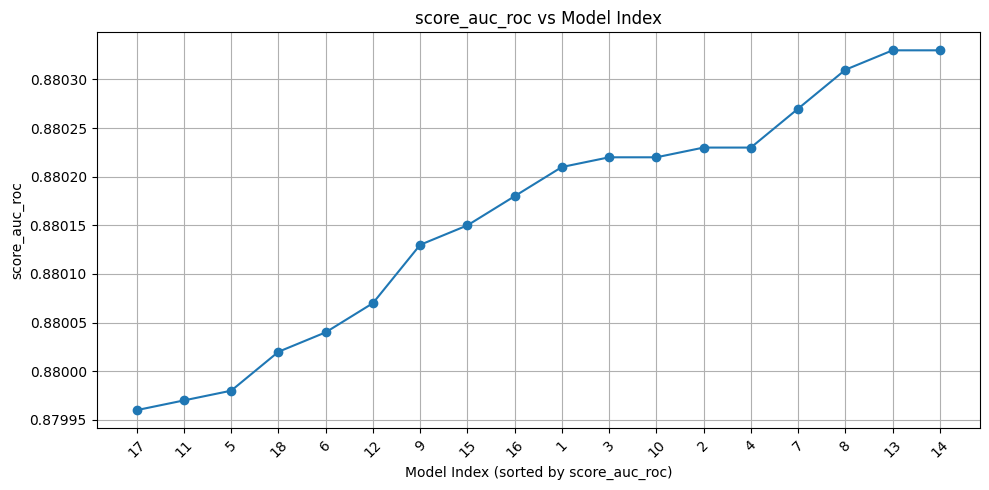

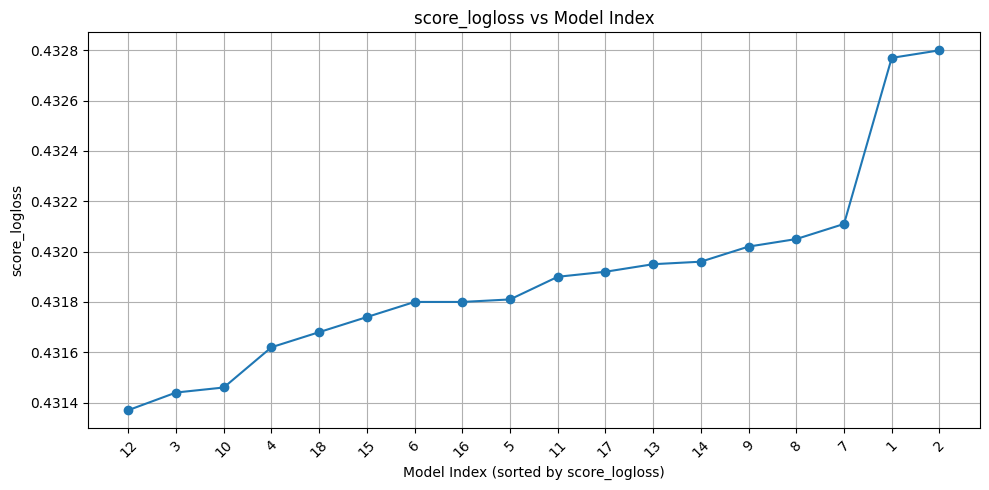

In [31]:
plot_metric(tuning_log_df, 'score_auc_roc')
plot_metric(tuning_log_df, 'score_logloss')

## 🧠 How eval_metric Works in CatBoost
In my modeling pipeline, I used CatBoost with **eval_metric='CrossEntropy'**, which is the metric monitored during training and used for early stopping. While it doesn’t directly influence the loss function (loss_function), it determines when the model stops learning.

I initially chose 'CrossEntropy' because it’s supported on GPU, making it much faster. However, 'AUC' is only available when training on CPU — which I now use — so switching to 'AUC' is a viable option that could better align with my goal of maximizing ROC AUC.

## 📊 What the Results Show
The models with the best AUC scores (e.g. 15, 24, 6…) do not perfectly align with those having the lowest logloss.

This suggests that optimizing for logloss doesn’t necessarily yield the best AUC, which aligns with theory:

Logloss measures how well the predicted probabilities match the actual outcomes.

AUC ROC measures the model’s ability to distinguish between classes.
## 🎯 Narrowing the Search Grid
Based on my analysis, it’s worth focusing on configurations around models 15–24:

Review key parameters like depth, learning_rate, and l2_leaf_reg from those models.

Build a tighter search grid — using only 2–3 values per parameter — to refine performance.

In [32]:
tuning_log_df.sort_values(by='score_auc_roc', ascending=False)

,model_index,score_auc_roc,score_logloss,duration_min,timestamp,loss_function,eval_metric,scale_pos_weight,learning_rate,iterations,depth,l2_leaf_reg,bagging_temperature,border_count,task_type,random_seed,verbose,early_stopping_rounds
13,14,0.88033,0.43196,23.76,15:17:10,Logloss,CrossEntropy,7,0.075,3000,8,10,1,254,GPU,42,0,200
12,13,0.88033,0.43195,23.72,14:53:24,Logloss,CrossEntropy,7,0.075,3000,8,6,1,254,GPU,42,0,200
7,8,0.88031,0.43205,23.50,13:04:08,Logloss,CrossEntropy,7,0.070,3000,8,10,1,254,GPU,42,0,200
6,7,0.88027,0.43211,23.33,12:40:38,Logloss,CrossEntropy,7,0.070,3000,8,6,1,254,GPU,42,0,200
3,4,0.88023,0.43162,27.47,11:32:55,Logloss,CrossEntropy,7,0.060,3000,9,10,1,254,GPU,42,0,200
1,2,0.88023,0.43280,23.27,10:38:01,Logloss,CrossEntropy,7,0.060,3000,8,10,1,254,GPU,42,0,200
9,10,0.88022,0.43146,24.13,13:49:27,Logloss,CrossEntropy,7,0.070,3000,9,10,1,254,GPU,42,0,200
2,3,0.88022,0.43144,27.44,11:05:27,Logloss,CrossEntropy,7,0.060,3000,9,6,1,254,GPU,42,0,200
0,1,0.88021,0.43277,23.58,10:14:44,Logloss,CrossEntropy,7,0.060,3000,8,6,1,254,GPU,42,0,200
15,16,0.88018,0.43180,21.24,15:59:27,Logloss,CrossEntropy,7,0.075,3000,9,10,1,254,GPU,42,0,200


In [33]:
selected_indices = [13, 14, 3, 12]
filtr = tuning_log_df['model_index'].isin(selected_indices)
subset = tuning_log_df[filtr]
subset.sort_values(by='score_auc_roc', ascending=False)

,model_index,score_auc_roc,score_logloss,duration_min,timestamp,loss_function,eval_metric,scale_pos_weight,learning_rate,iterations,depth,l2_leaf_reg,bagging_temperature,border_count,task_type,random_seed,verbose,early_stopping_rounds
13,14,0.88033,0.43196,23.76,15:17:10,Logloss,CrossEntropy,7,0.075,3000,8,10,1,254,GPU,42,0,200
12,13,0.88033,0.43195,23.72,14:53:24,Logloss,CrossEntropy,7,0.075,3000,8,6,1,254,GPU,42,0,200
2,3,0.88022,0.43144,27.44,11:05:27,Logloss,CrossEntropy,7,0.060,3000,9,6,1,254,GPU,42,0,200
11,12,0.88007,0.43137,21.31,14:29:40,Logloss,CrossEntropy,7,0.070,3000,10,10,1,254,GPU,42,0,200


In [34]:

for i in selected_indices:
    filtr = tuning_log_df['model_index'] == i 
    params = tuning_log_df[filtr].drop(columns=[
        'model_index', 'score_auc_roc', 'score_logloss',
        'duration_min', 'timestamp', 'loss_function', 'eval_metric'
    ])
    
    if not params.empty:
        params_dict = params.iloc[0].to_dict()
        print(f"\nParameters for model_index {i}:")
        print(params_dict)

        # Updating 'eval_metric' to AUC
        params_dict['eval_metric'] = 'AUC'
        print(f"\nFinal parameters with AUC for model_index {i}:")
        print(params_dict)

        # Training model
        cat_clf, cat_params, df_model_results, p_test_cat_clf = train_catboost_baseline_auc(
            X_train_pool, X_valid_pool, X_test_pool, y_valid_split,
            df_model=df_model_results,
            model_name=f"CatBoost_baseline_AUC_{i}",  
            custom_params=params_dict
        )
    else:
        print(f"\n⚠️ No data found for model_index = {i}")


Parameters for model_index 13:
{'scale_pos_weight': 7, 'learning_rate': 0.075, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 6, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}

Final parameters with AUC for model_index 13:
{'scale_pos_weight': 7, 'learning_rate': 0.075, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 6, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200, 'eval_metric': 'AUC'}

--- Starting CatBoost Training at 16:51:08 ---


Default metric period is 5 because AUC is/are not implemented for GPU



Validation ROC AUC Score: 0.88031
Model Training Time: 24.64 minutes

Parameters for model_index 14:
{'scale_pos_weight': 7, 'learning_rate': 0.075, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}

Final parameters with AUC for model_index 14:
{'scale_pos_weight': 7, 'learning_rate': 0.075, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200, 'eval_metric': 'AUC'}

--- Starting CatBoost Training at 17:15:47 ---


Default metric period is 5 because AUC is/are not implemented for GPU



Validation ROC AUC Score: 0.88032
Model Training Time: 25.51 minutes

Parameters for model_index 3:
{'scale_pos_weight': 7, 'learning_rate': 0.06, 'iterations': 3000, 'depth': 9, 'l2_leaf_reg': 6, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}

Final parameters with AUC for model_index 3:
{'scale_pos_weight': 7, 'learning_rate': 0.06, 'iterations': 3000, 'depth': 9, 'l2_leaf_reg': 6, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200, 'eval_metric': 'AUC'}

--- Starting CatBoost Training at 17:41:18 ---


Default metric period is 5 because AUC is/are not implemented for GPU



Validation ROC AUC Score: 0.88021
Model Training Time: 29.01 minutes

Parameters for model_index 12:
{'scale_pos_weight': 7, 'learning_rate': 0.07, 'iterations': 3000, 'depth': 10, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}

Final parameters with AUC for model_index 12:
{'scale_pos_weight': 7, 'learning_rate': 0.07, 'iterations': 3000, 'depth': 10, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200, 'eval_metric': 'AUC'}

--- Starting CatBoost Training at 18:10:18 ---


Default metric period is 5 because AUC is/are not implemented for GPU



Validation ROC AUC Score: 0.88012
Model Training Time: 28.50 minutes


In [36]:
df_model_results = df_model_results.sort_values(by='score', ascending=False)
selected_indices = [17, 18, 20, 16, 1, 3, 2, 0]
filtered_df = df_model_results.loc[selected_indices]
filtered_df

,model_name,score,duration_min,timestamp,metric,loss_function,eval_metric,scale_pos_weight,learning_rate,iterations,depth,l2_leaf_reg,bagging_temperature,border_count,task_type,random_seed,verbose,early_stopping_rounds
17,catboost_tune,0.88033,23.72,14:53:24,ROC AUC,Logloss,CrossEntropy,7.0,0.075,3000.0,8.0,6.0,1.0,254.0,GPU,42.0,0.0,200.0
18,catboost_tune,0.88033,23.76,15:17:10,ROC AUC,Logloss,CrossEntropy,7.0,0.075,3000.0,8.0,10.0,1.0,254.0,GPU,42.0,0.0,200.0
20,CatBoost_baseline_AUC_14,0.88032,25.51,17:15:47,ROC AUC,NaN,AUC,7.0,0.075,3000.0,8.0,10.0,1.0,254.0,GPU,42.0,0.0,200.0
16,catboost_tune,0.88031,23.50,13:04:08,ROC AUC,Logloss,CrossEntropy,7.0,0.070,3000.0,8.0,10.0,1.0,254.0,GPU,42.0,0.0,200.0
1,xgboost,0.87709,0.38,22:15:02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CatBoost_baseline,0.87665,26.09,22:17:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lightgbm,0.87620,0.33,22:15:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,random_forest,0.84411,36.56,21:38:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###### Final Robust Validation: Stratified K-Fold Ensembling
To achieve the highest possible score and ensure the model's robustness, the best-tuned parameters were implemented in a Stratified K-Fold Cross-Validation (SKF) ensemble strategy with $N=2$ Folds.
Methodology:
- Variance Reduction: Training multiple models on different subsets of the data (folds) and averaging their predictions (Ensembling) significantly reduces model variance, leading to a more stable and reliable prediction.
- Stratification: The StratifiedKFold technique was used to ensure the severe class imbalance in the target variable (Response) was maintained across all training and validation folds.
- Final Prediction: The ultimate submission probability (p_test) was calculated as the mean of the predictions generated by the model from each individual fold ($\text{test\_preds.mean(axis=1)}$).

In [37]:
def train_catboost_kfold(X_train_full, y_train_full, X_test, list_cat_columns, model_params=None, folds=5, random_state=42):
    import time
    import numpy as np
    import gc
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score
    from catboost import CatBoostClassifier, Pool

    start_time = time.time()
    scores = []
    test_preds_folds = np.zeros((len(X_test), folds), dtype=np.float32)

    # Domyślne parametry modelu, jeśli nie podano
    if model_params is None:
        positive_count = y_train_full.sum()
        negative_count = len(y_train_full) - positive_count
        scale_pos_weight = int(negative_count / positive_count)

        model_params = {
            'loss_function': 'Logloss',
            'eval_metric': 'CrossEntropy',
            'scale_pos_weight': scale_pos_weight,
            'learning_rate': 0.075,
            'depth': 8,
            'iterations': 3000,
            'l2_leaf_reg': 6,
            'task_type': 'GPU',
            'early_stopping_rounds': 200,
            'verbose': 0
        }
    else:
        print("params has been pased/n",model_params)
        
    print("/nfolds =",folds,"/nmodel_params=",model_params)
    
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        print("#" * 50)
        print(f"# Fold {fold + 1} / {folds}")
        print("#" * 50)

        X_train_fold = X_train_full.iloc[train_idx]
        y_train_fold = y_train_full.iloc[train_idx]
        X_val_fold   = X_train_full.iloc[val_idx]
        y_val_fold   = y_train_full.iloc[val_idx]

        train_pool = Pool(X_train_fold, y_train_fold, cat_features=list_cat_columns)
        val_pool   = Pool(X_val_fold, y_val_fold, cat_features=list_cat_columns)
        test_pool  = Pool(X_test, cat_features=list_cat_columns)

        model = CatBoostClassifier(**model_params)
        model.fit(train_pool, eval_set=val_pool, verbose=model_params['verbose'],
                  early_stopping_rounds=model_params['early_stopping_rounds'])

        test_preds_folds[:, fold] = model.predict_proba(test_pool)[:, 1]
        val_preds = model.predict_proba(val_pool)[:, 1]
        auc = roc_auc_score(y_val_fold, val_preds)
        scores.append(auc)
        print(f'Fold {fold + 1} ROC AUC: {auc:.5f}')

        del model, train_pool, val_pool, test_pool
        gc.collect()

    final_test_prediction = test_preds_folds.mean(axis=1)
    mean_auc = np.mean(scores)
    duration = (time.time() - start_time) / 60

    print("=" * 50)
    print(f"Mean Validation ROC AUC: {mean_auc:.5f}")
    print(f"Total K-Fold Execution Time: {duration:.2f} minutes")

    return final_test_prediction, scores, mean_auc

In [38]:

X_train_full_cat = pd.concat([X_train_cat, X_valid_cat], ignore_index=True)
y_train_full_cat = pd.concat([y_train_split, y_valid_split], ignore_index=True)


In [39]:
final_preds, fold_scores, avg_auc = train_catboost_kfold(
    X_train_full=X_train_full_cat,
    y_train_full=y_train_full_cat,
    X_test= X_test_cat,
    list_cat_columns=list_cat_columns,
    folds=2,  
    model_params=best_params_cat_tune
)

params has been pased/n {'loss_function': 'Logloss', 'eval_metric': 'CrossEntropy', 'scale_pos_weight': 7, 'learning_rate': 0.075, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}
/nfolds = 2 /nmodel_params= {'loss_function': 'Logloss', 'eval_metric': 'CrossEntropy', 'scale_pos_weight': 7, 'learning_rate': 0.075, 'iterations': 3000, 'depth': 8, 'l2_leaf_reg': 10, 'bagging_temperature': 1, 'border_count': 254, 'task_type': 'GPU', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 200}
##################################################
# Fold 1 / 2
##################################################
Fold 1 ROC AUC: 0.87966
##################################################
# Fold 2 / 2
##################################################
Fold 2 ROC AUC: 0.87995
Mean Validation ROC AUC: 0.87981
Total K-Fold Execution Time: 30.52 minutes


In [40]:
print(final_preds)

[4.8711993e-02 8.3435702e-01 6.7950511e-01 ... 1.2959747e-03 9.0599775e-01
 3.5742024e-04]


# AUC ROC  0.87981
## 💾 Save submmision data to CSV

In [41]:

submission_df = pd.DataFrame({
    'id': test_indices,
    'prediction': final_preds
})

# Zapis do pliku CSV
submission_df.to_csv('submission.csv', index=False)
print(submission_df)

               id  prediction
0        11504798    0.048712
1        11504799    0.834357
2        11504800    0.679505
3        11504801    0.000693
4        11504802    0.328335
...           ...         ...
7669861  19174659    0.659901
7669862  19174660    0.001119
7669863  19174661    0.001296
7669864  19174662    0.905998
7669865  19174663    0.000357

[7669866 rows x 2 columns]
